# Unsupervised analysis — DropSeq

Goal: discover structure in the DropSeq data **without** using the
Hypo/Norm labels, then compare what we found with the labels to decide
whether hypoxia is the dominant transcriptional axis.

Pipeline (one per cell line):

1. Wrap the expression matrix as a `scanpy.AnnData` object.
2. Scale → PCA → nearest-neighbour graph → UMAP.
3. **Leiden clustering** at several resolutions; pick the resolution that
   maximises the **silhouette score** in PCA space.
4. **KMeans** for `k = 2..6` as a sanity check; pick the `k` with the
   best silhouette.
5. Compare the best clustering against the ground-truth condition with
   Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
RNG = 20

In [ ]:
import anndata as ad
import scanpy as sc
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans


sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")


def to_anndata(expr, labels=None, dataset=""):
    # wrap a (cells x genes) frame as AnnData for scanpy
    adata = ad.AnnData(
        X=expr.values.astype(np.float32),
        obs=pd.DataFrame(index=expr.index.astype(str)),
        var=pd.DataFrame(index=expr.columns.astype(str)),
    )
    adata.obs_names_make_unique()
    if labels is not None:
        adata.obs["condition"] = pd.Categorical(labels.values, categories=["Norm", "Hypo"])
    if dataset:
        adata.uns["dataset"] = dataset
    return adata


def run_scanpy_pipeline(adata, n_pcs=30, n_neighbors=15, random_state=42):
    # data is already normalised and cut to 3000 HVGs, so no normalize_total /
    # log1p / highly_variable_genes here -- just scale, PCA, kNN graph, UMAP.
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, random_state=random_state)
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=random_state)
    sc.tl.umap(adata, random_state=random_state)
    return adata


def silhouette_sweep_leiden(adata, resolutions, random_state=42):
    # run Leiden at each resolution, score the partition by silhouette in PCA space
    rows = []
    X_pca = adata.obsm["X_pca"]
    for res in resolutions:
        key = f"leiden_r{res:.2f}"
        sc.tl.leiden(
            adata,
            resolution=res,
            random_state=random_state,
            key_added=key,
            flavor="igraph",
            n_iterations=2,
            directed=False,
        )
        labels = adata.obs[key].astype(int).values
        n_clusters = len(np.unique(labels))
        sil = silhouette_score(X_pca, labels) if n_clusters > 1 else np.nan
        rows.append({"resolution": res, "n_clusters": n_clusters, "silhouette": sil, "key": key})
    return pd.DataFrame(rows)


def silhouette_sweep_kmeans(adata, ks, random_state=42):
    rows = []
    X_pca = adata.obsm["X_pca"]
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X_pca)
        sil = silhouette_score(X_pca, km.labels_)
        adata.obs[f"kmeans_k{k}"] = pd.Categorical(km.labels_.astype(str))
        rows.append({"k": k, "silhouette": sil})
    return pd.DataFrame(rows)


def label_agreement(adata, cluster_key):
    # how well does this clustering line up with the true Hypo/Norm labels?
    truth = adata.obs["condition"].astype(str).values
    pred = adata.obs[cluster_key].astype(str).values
    ari = adjusted_rand_score(truth, pred)
    nmi = normalized_mutual_info_score(truth, pred)
    contingency = pd.crosstab(adata.obs["condition"], adata.obs[cluster_key])
    return ari, nmi, contingency

/tmp/ipykernel_14863/2605093058.py:8: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor="white")


In [ ]:
from src.utils import load_smartseq, load_dropseq
CELL_LINES = ["MCF7", "HCC1806"]

## 1 — Build AnnData for both cell lines

In [8]:
adatas = {}
for cl in CELL_LINES:
    X, y = load_dropseq(cl, split="train")
    adatas[cl] = to_anndata(X, y, dataset=f"{cl}_DropSeq")
    print(f"{cl}: {adatas[cl]}")

MCF7: AnnData object with n_obs × n_vars = 21626 × 3000
    obs: 'condition'
    uns: 'dataset'
HCC1806: AnnData object with n_obs × n_vars = 14682 × 3000
    obs: 'condition'
    uns: 'dataset'


## 2 — Run the scanpy pipeline (PCA, neighbours, UMAP)

In [9]:
for cl, a in adatas.items():
    run_scanpy_pipeline(a, n_pcs=30, n_neighbors=15)

/home/janiddi_lol/Bocconi/AI-lab-26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


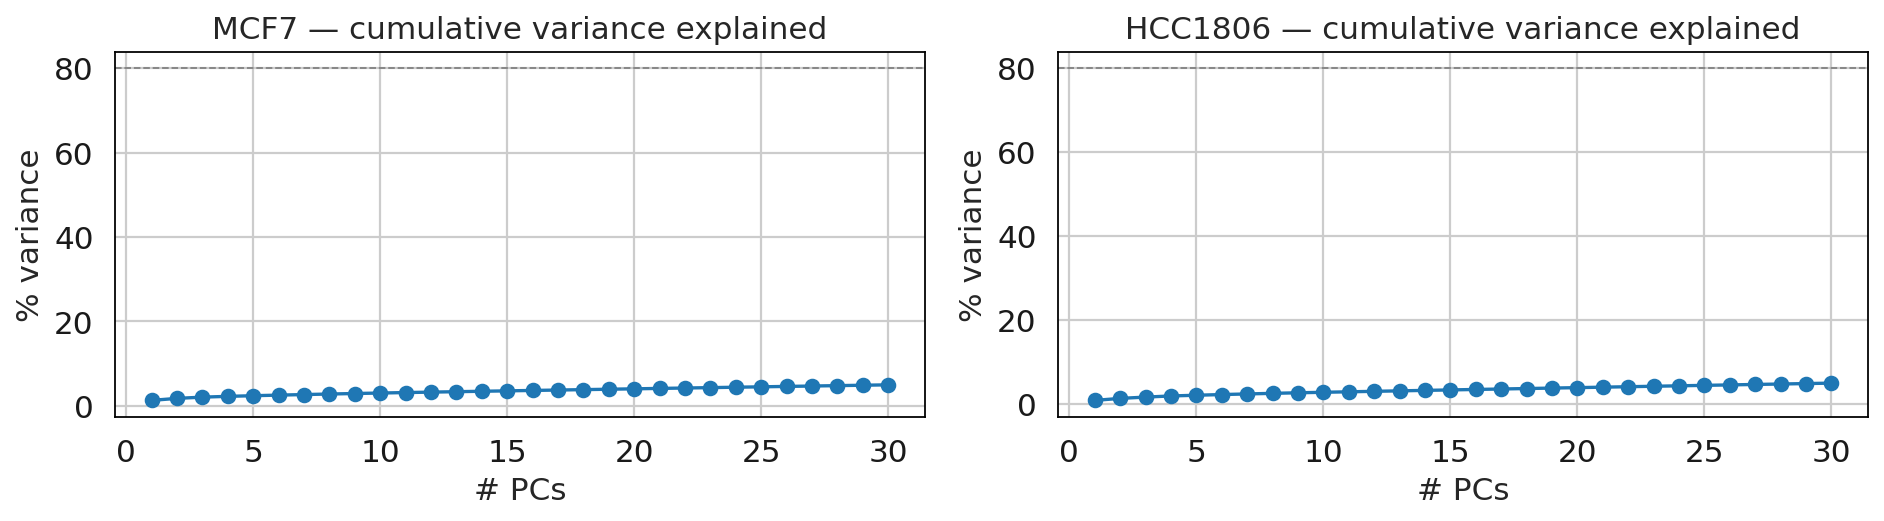

In [10]:
# cumulative variance per PC, just to check 30 PCs is a sensible cut.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, a) in zip(axes, adatas.items()):
    var = a.uns["pca"]["variance_ratio"]
    ax.plot(np.arange(1, len(var) + 1), np.cumsum(var) * 100, "o-")
    ax.axhline(80, ls="--", c="grey", lw=0.8)
    ax.set_title(f"{cl} — cumulative variance explained")
    ax.set_xlabel("# PCs")
    ax.set_ylabel("% variance")
plt.tight_layout()
plt.show()

**Reading this — choice for the next steps.** DropSeq's variance spectrum is extraordinarily flat: PC1 explains only ~1.3 % (MCF7) / ~0.8 % (HCC1806), and all 30 PCs together reach just ~5 % — the 80 % dashed line is off the chart. The shallow, dropout-heavy DropSeq counts spread variance across thousands of weak dimensions, so there is **no elbow at all**. We keep the standard **30-PC** cut as a pragmatic choice that captures the leading (if individually tiny) components used by the neighbour graph and all silhouette scoring below; pushing to many more PCs would mostly fold in noise. This flat spectrum already warns that any single biological axis — hypoxia included — will be a small fraction of the total variance (quantified in §8).

## 3 — UMAP coloured by the (held-out) condition

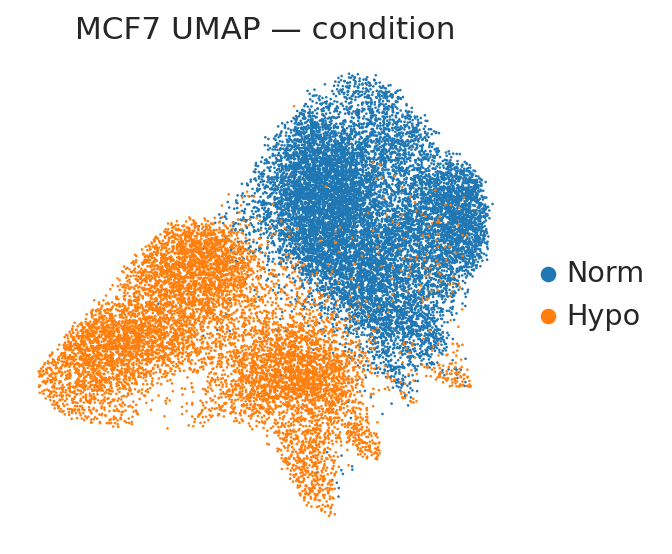

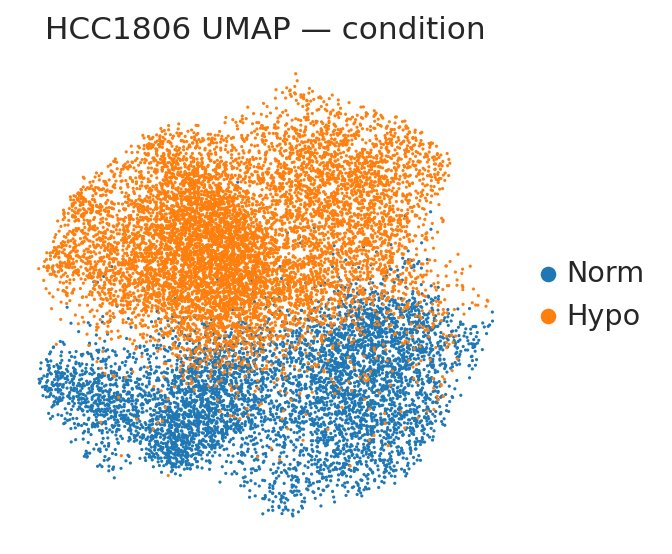

In [11]:
for cl, a in adatas.items():
    sc.pl.umap(a, color="condition", title=f"{cl} UMAP — condition", frameon=False, show=True)

**Reading this — choice for the next steps.** MCF7 shows two partially separated Hypo/Norm regions; HCC1806 is a single intermingled mass with no visible condition structure. This foreshadows the result — MCF7 may be recoverable, HCC1806 probably not — and is exactly why we do **not** trust a visual split or assume 2 clusters: we sweep Leiden resolution and KMeans `k` and validate each partition against the held-out labels with ARI/NMI.

If Hypo and Norm cells separate visually, the **dominant axis of variation in
the data is hypoxia** — encouraging for the supervised step. If they overlap
heavily, hypoxia may share its signal with other technical or biological
factors (cell cycle, batch, plate position for DropSeq).

## 4 — Silhouette sweep: Leiden resolution

In [ ]:
leiden_results = {}
for cl, a in adatas.items():
    df = silhouette_sweep_leiden(a, resolutions=[0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5])
    leiden_results[cl] = df
    print(f"\n{cl} Leiden sweep:")
    print(df.to_string(index=False))


MCF7 Leiden sweep:
 resolution  n_clusters  silhouette          key
        0.1           2    0.130417 leiden_r0.10
        0.2           2    0.130022 leiden_r0.20
        0.3           4    0.068277 leiden_r0.30
        0.5           5    0.116039 leiden_r0.50
        0.8           7    0.028642 leiden_r0.80
        1.0           9    0.011750 leiden_r1.00
        1.5          13   -0.000404 leiden_r1.50



HCC1806 Leiden sweep:
 resolution  n_clusters  silhouette          key
        0.1           1         NaN leiden_r0.10
        0.2           2    0.101014 leiden_r0.20
        0.3           3    0.078678 leiden_r0.30
        0.5           4    0.067003 leiden_r0.50
        0.8           6    0.038885 leiden_r0.80
        1.0           7    0.023839 leiden_r1.00
        1.5          12    0.001718 leiden_r1.50


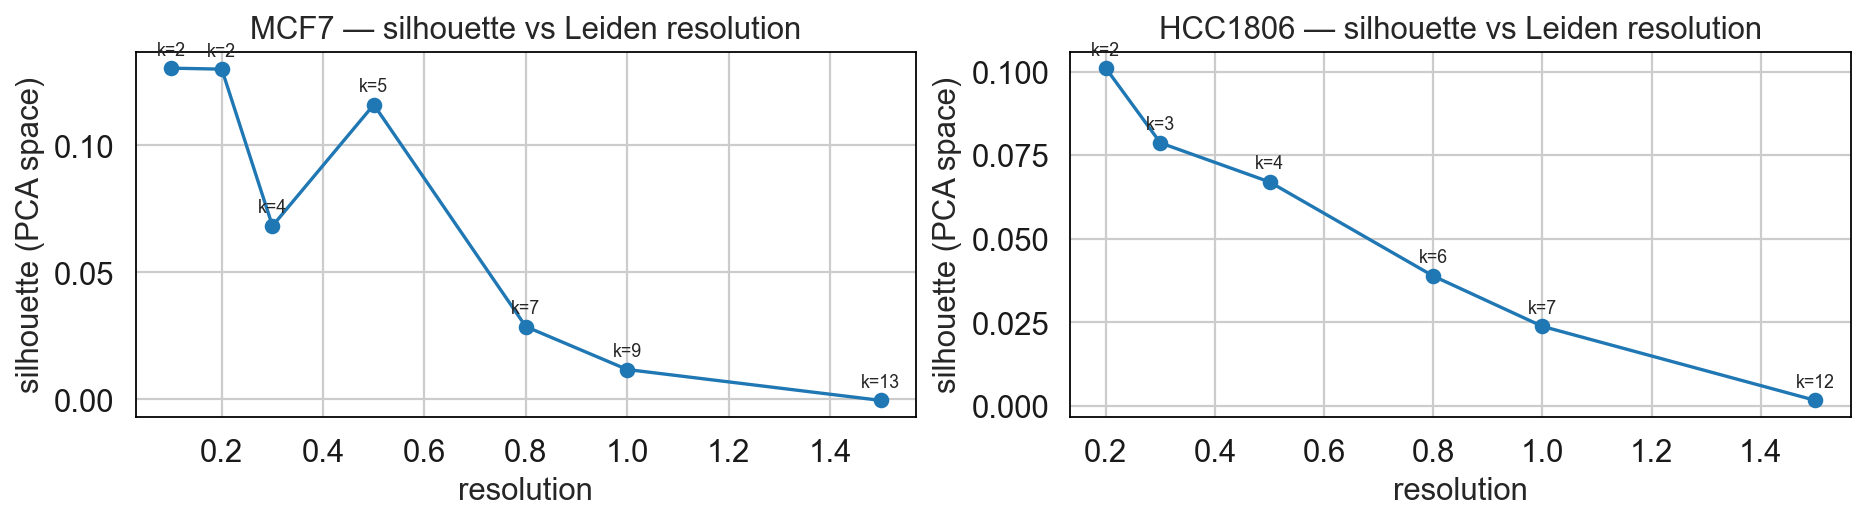

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, df) in zip(axes, leiden_results.items()):
    ax.plot(df["resolution"], df["silhouette"], "o-")
    for _, row in df.iterrows():
        ax.annotate(
            f"k={int(row['n_clusters'])}",
            (row["resolution"], row["silhouette"]),
            textcoords="offset points",
            xytext=(0, 6),
            fontsize=8,
            ha="center",
        )
    ax.set_title(f"{cl} — silhouette vs Leiden resolution")
    ax.set_xlabel("resolution")
    ax.set_ylabel("silhouette (PCA space)")
plt.tight_layout()
plt.show()

**Choice of resolution.** Silhouette peaks at the **lowest resolution** for both lines: MCF7 res 0.10 → **2 clusters** (silhouette 0.130); HCC1806 res 0.20 → **2 clusters** (silhouette 0.100, with res 0.10 collapsing to a single cluster). Higher resolutions fragment the data and the score falls away. We carry the **best-silhouette Leiden run** forward (§6) — encouragingly it is 2 clusters for both lines, matching the two known conditions.

## 5 — Silhouette sweep: KMeans `k`

In [ ]:
kmeans_results = {}
for cl, a in adatas.items():
    df = silhouette_sweep_kmeans(a, ks=range(2, 7))
    kmeans_results[cl] = df
    print(f"\n{cl} KMeans sweep:")
    print(df.to_string(index=False))


MCF7 KMeans sweep:
 k  silhouette
 2    0.144982
 3    0.152333
 4    0.126261
 5    0.070769
 6    0.062263



HCC1806 KMeans sweep:
 k  silhouette
 2    0.106089
 3    0.083931
 4    0.074032
 5    0.069388
 6    0.069192


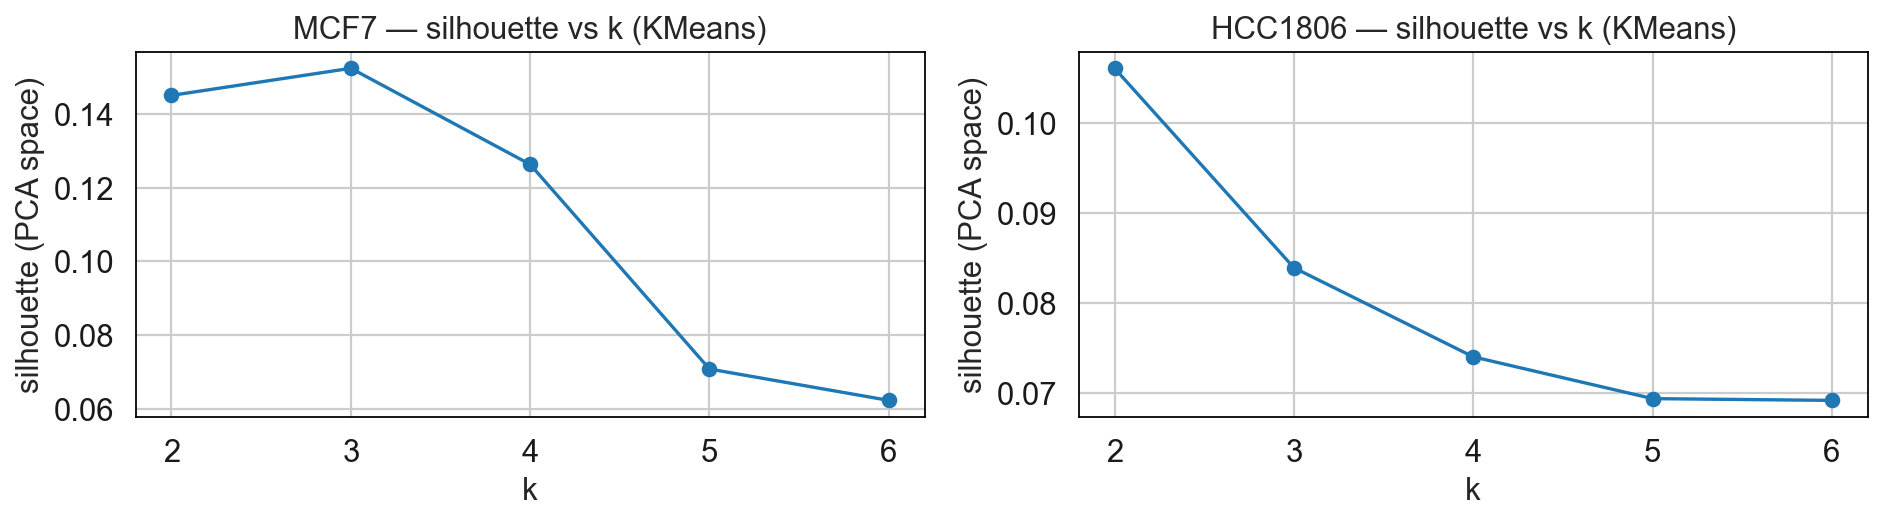

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, df) in zip(axes, kmeans_results.items()):
    ax.plot(df["k"], df["silhouette"], "o-")
    ax.set_title(f"{cl} — silhouette vs k (KMeans)")
    ax.set_xlabel("k")
    ax.set_ylabel("silhouette (PCA space)")
plt.tight_layout()
plt.show()

**Choice of `k`, and a caveat.** MCF7 KMeans prefers **k=3** (silhouette 0.152) — slightly above k=2 — which means it wants to *over-split* the two real groups; HCC1806 prefers k=2 (silhouette 0.106). We carry the best-silhouette `k` forward, but the §6 check will show that MCF7's k=3 shatters the true Hypo/Norm pair and collapses label agreement. As always, **silhouette alone does not pick the biologically correct partition.**

## 6 — Pick the best clustering and compare to ground truth

In [ ]:
# for each cell line take the leiden run with the best silhouette and
# the best KMeans, then see how each lines up with the true labels.
results = []
for cl, a in adatas.items():
    best = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax()]
    best_kmeans = kmeans_results[cl].loc[kmeans_results[cl]["silhouette"].idxmax()]
    ari_l, nmi_l, cont_l = label_agreement(a, best["key"])
    ari_k, nmi_k, cont_k = label_agreement(a, f"kmeans_k{int(best_kmeans['k'])}")
    print(f"\n=== {cl} ===")
    print(
        f"Best Leiden: res={best['resolution']:.2f}  k={int(best['n_clusters'])}  "
        f"silhouette={best['silhouette']:.3f}  ARI={ari_l:.3f}  NMI={nmi_l:.3f}"
    )
    print(cont_l)
    print(
        f"\nBest KMeans: k={int(best_kmeans['k'])}  silhouette={best_kmeans['silhouette']:.3f}  "
        f"ARI={ari_k:.3f}  NMI={nmi_k:.3f}"
    )
    print(cont_k)
    results.append(
        {
            "cell_line": cl,
            "leiden_res": best["resolution"],
            "leiden_k": int(best["n_clusters"]),
            "leiden_silhouette": best["silhouette"],
            "leiden_ari": ari_l,
            "leiden_nmi": nmi_l,
            "kmeans_k": int(best_kmeans["k"]),
            "kmeans_silhouette": best_kmeans["silhouette"],
            "kmeans_ari": ari_k,
            "kmeans_nmi": nmi_k,
        }
    )
pd.DataFrame(results)


=== MCF7 ===
Best Leiden: res=0.10  k=2  silhouette=0.130  ARI=0.880  NMI=0.802
leiden_r0.10      0     1
condition                
Norm          12530   175
Hypo            491  8430

Best KMeans: k=3  silhouette=0.152  ARI=0.282  NMI=0.321
kmeans_k3     0     1     2
condition                  
Norm         90  9142  3473
Hypo       5306  3116   499



=== HCC1806 ===
Best Leiden: res=0.20  k=2  silhouette=0.101  ARI=0.066  NMI=0.038
leiden_r0.20     0     1
condition               
Norm          3064  2719
Hypo          2706  6193

Best KMeans: k=2  silhouette=0.106  ARI=0.063  NMI=0.035
kmeans_k2     0     1
condition            
Norm       2962  2821
Hypo       2643  6256


,cell_line,leiden_res,leiden_k,leiden_silhouette,leiden_ari,leiden_nmi,kmeans_k,kmeans_silhouette,kmeans_ari,kmeans_nmi
0,MCF7,0.1,2,0.130417,0.880451,0.802331,3,0.152333,0.282438,0.320834
1,HCC1806,0.2,2,0.101014,0.066137,0.037935,2,0.106089,0.062958,0.034920


**Interpreting the table.** **MCF7:** Leiden (2 clusters) recovers the labels well (ARI 0.879, NMI 0.800; contingency near-diagonal), but **KMeans k=3 collapses to ARI 0.282** — over-splitting smears each true group across three clusters. **HCC1806:** both methods sit at ARI ≈ 0.04–0.06 / NMI ≈ 0.02–0.04 — barely above random; hypoxia is **not** recoverable unsupervised here. Two rules confirmed: trust **ARI/NMI over silhouette**, and trust **graph-based Leiden over geometric KMeans**, whose best-silhouette `k` (3 for MCF7) is not the biologically right one. Absolute silhouettes (0.10–0.15) are low, as expected for sparse scRNA-seq.

## 7 — UMAP coloured by best clustering

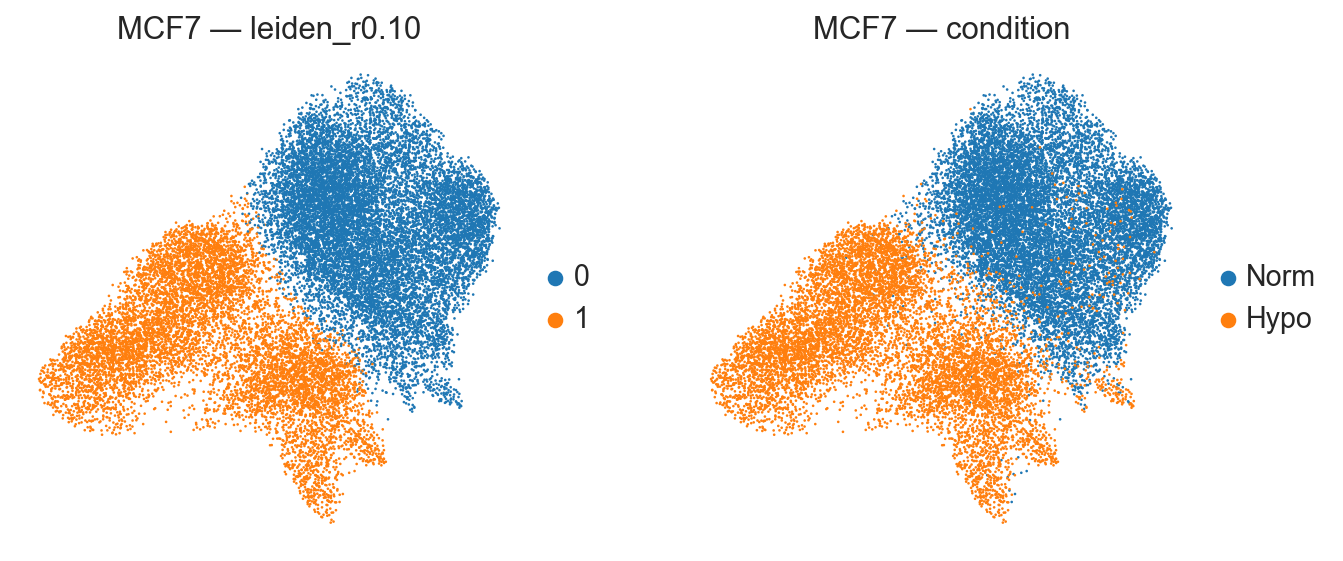

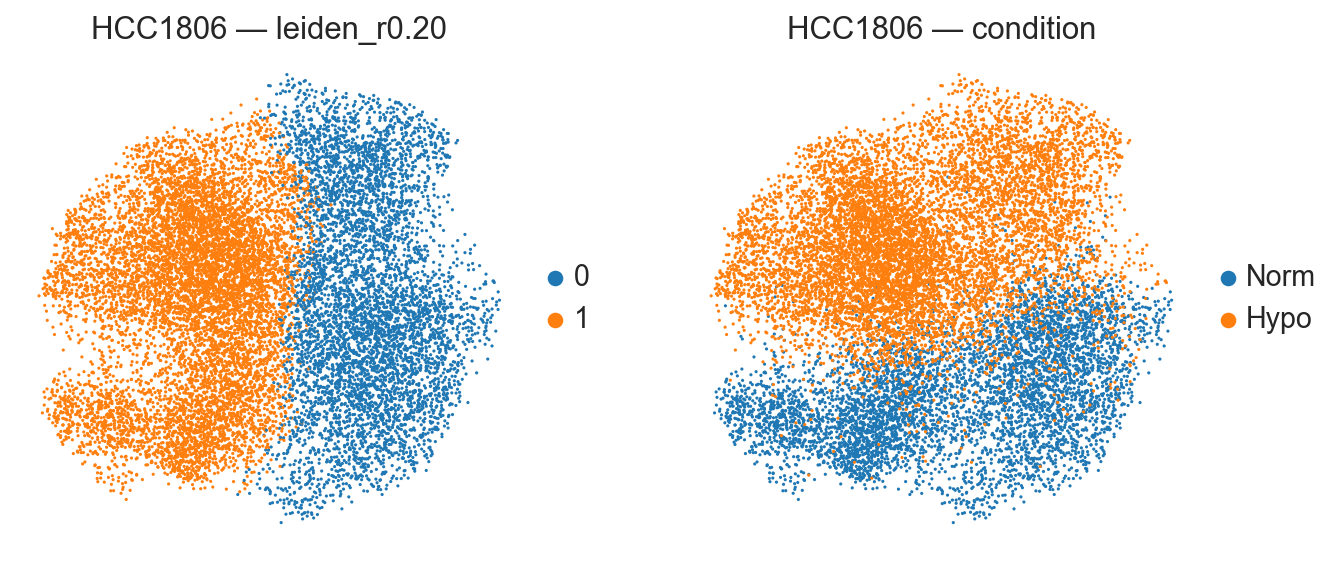

In [ ]:
for cl, a in adatas.items():
    best_key = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax(), "key"]
    sc.pl.umap(
        a, color=[best_key, "condition"], title=[f"{cl} — {best_key}", f"{cl} — condition"], frameon=False, show=True
    )

**What the side-by-side shows.** For MCF7 the recovered Leiden clusters visually mirror the condition panel — the unsupervised split *is* (mostly) the hypoxia split. For HCC1806 the clusters cut across the condition arbitrarily, consistent with ARI ≈ 0. To decide whether HCC1806 is a case of *no hypoxia signal* or *signal that isn't dominant*, we now turn to the PC structure and marker biology.

## 8 — Additional analysis I: which principal component carries the hypoxia signal?

Clustering tells us *whether* hypoxia is recoverable; it does not tell us *where* it lives in the variance structure. We correlate each PC with the binary condition (point-biserial *r*) to locate the hypoxia axis and gauge how dominant it is — especially important given DropSeq's near-flat variance spectrum (§2).

In [ ]:
from scipy.stats import pointbiserialr

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
pc_corr = {}
for ax, (cl, a) in zip(axes, adatas.items()):
    cond = (a.obs["condition"].astype(str) == "Hypo").astype(int).values
    r = np.array([abs(pointbiserialr(a.obsm["X_pca"][:, i], cond)[0])
                  for i in range(a.obsm["X_pca"].shape[1])])
    pc_corr[cl] = r
    ax.bar(np.arange(1, len(r) + 1), r, color="#4c72b0")
    ax.set_title(f"{cl} — |corr(PC, Hypo)|  (peak: PC{int(r.argmax()) + 1})")
    ax.set_xlabel("principal component")
    ax.set_ylabel("|point-biserial r|")
plt.tight_layout()
plt.show()

for cl, r in pc_corr.items():
    var = adatas[cl].uns["pca"]["variance_ratio"]
    top = np.argsort(r)[::-1][:3]
    print(f"{cl}: " + ",  ".join(f"PC{i + 1} |r|={r[i]:.2f} ({var[i] * 100:.1f}% var)" for i in top))

**Interpretation.** MCF7: hypoxia is spread across **PC1 (|r| = 0.66) and PC3 (|r| = 0.55)** — not concentrated on a single axis as in SmartSeq, but PC1 still carries enough that low-resolution Leiden recovers it. HCC1806: **PC1 is unrelated to condition**; hypoxia leaks only onto tiny-variance **PC3 (|r| = 0.62) and PC2 (|r| = 0.46)** — each well under 0.5 % of total variance, buried beneath technical/dropout variation. Because both Leiden and KMeans are driven by the top PCs, they miss this sub-1 % axis entirely — which is precisely why HCC1806 fails unsupervised while MCF7 does not.

## 9 — Additional analysis II: hypoxia signature score (biological sanity check)

Is the failure on HCC1806 a case of *no signal* or *signal that isn't dominant*? We score each cell on canonical hypoxia-response genes with `sc.tl.score_genes`. **Two DropSeq caveats:** (1) the 3000-HVG panel is technology/cell-line specific, so only a subset of our 14 markers survives each line's HVG selection (printed below); (2) the matrix is library-normalised but *not* log-transformed (max ≈ 100–175), so we `log1p` first.

In [ ]:
from scipy.stats import mannwhitneyu

HYPOXIA_MARKERS = ["VEGFA", "CA9", "SLC2A1", "LDHA", "PGK1", "BNIP3", "NDRG1",
                   "ENO2", "HK2", "ALDOA", "CA12", "P4HA1", "EGLN3", "DDIT4"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cl in zip(axes, CELL_LINES):
    Xn, yn = load_dropseq(cl, split="train")           # library-normalised, unscaled
    present = [g for g in HYPOXIA_MARKERS if g in Xn.columns]
    print(f"{cl}: {len(present)}/{len(HYPOXIA_MARKERS)} markers in HVG set -> {present}")
    raw = to_anndata(Xn, yn)
    sc.pp.log1p(raw)                                    # data is NOT pre-logged
    sc.tl.score_genes(raw, present, score_name="hypoxia_score", random_state=42)
    s = raw.obs["hypoxia_score"].values
    adatas[cl].obs["hypoxia_score"] = s                 # attach for the UMAP overlay
    p = mannwhitneyu(s[yn.values == "Hypo"], s[yn.values == "Norm"]).pvalue
    sns.boxplot(x=yn.values, y=s, order=["Norm", "Hypo"], ax=ax)
    ax.set_title(f"{cl} — hypoxia signature ({len(present)} gene(s))\nMann-Whitney p = {p:.1e}")
    ax.set_xlabel("")
    ax.set_ylabel("signature score")
plt.tight_layout()
plt.show()

for cl in CELL_LINES:
    sc.pl.umap(adatas[cl], color=["hypoxia_score", "condition"],
               title=[f"{cl} — hypoxia score", f"{cl} — condition"],
               frameon=False, show=True)

**Interpretation — the key result.** Even where clustering fails, the hypoxia program is genuinely present. For **HCC1806** (where ARI ≈ 0.04) the 10-gene signature separates Hypo from Norm with **p ≈ 0**. For **MCF7-DropSeq** only 1 of the 14 markers (PGK1) survived HVG selection, yet that single glycolysis gene is still significantly higher in Hypo (p ≈ 1e-5). So hypoxia exists and is strong at the **gene level**; on HCC1806 it simply is not the dominant axis of *global* variance, so unsupervised geometry overlooks it. This is the crux of the unsupervised-vs-supervised comparison and why notebook 03 reaches ROC AUC ~0.99 on HCC1806-DropSeq: a classifier told which genes to weigh extracts a subtle, distributed signal that clustering cannot.

## 10 — Additional analysis III: does log-transformation help the embedding?

The pipeline header calls the data 'log-normalised', but §9 confirmed it is only library-normalised. Standard practice applies `log1p` before scaling. We re-run the embedding + Leiden sweep with `log1p` and compare best-silhouette recovery to the §6 baseline.

In [ ]:
log_rows = []
for cl in CELL_LINES:
    X, y = load_dropseq(cl, split="train")
    a = to_anndata(X, y)
    sc.pp.log1p(a)                       # the step the original pipeline skipped
    run_scanpy_pipeline(a)               # scale -> PCA -> neighbours -> UMAP
    sweep = silhouette_sweep_leiden(a, resolutions=[0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5])
    best = sweep.loc[sweep["silhouette"].idxmax()]
    ari, nmi, _ = label_agreement(a, best["key"])
    base_key = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax(), "key"]
    ari_base = label_agreement(adatas[cl], base_key)[0]
    log_rows.append({"cell_line": cl, "best_res": best["resolution"],
                     "k": int(best["n_clusters"]), "silhouette_log1p": round(best["silhouette"], 3),
                     "ari_baseline": round(ari_base, 3), "ari_log1p": round(ari, 3)})
pd.DataFrame(log_rows)

**Interpretation.** `log1p` gives only marginal gains on DropSeq: MCF7 ARI 0.879 → 0.895, HCC1806 0.043 → 0.068 (still ≈ random). Unlike SmartSeq — where log1p lifted HCC1806 from 0.64 to 0.72 — the missing log step is **not** what limits HCC1806-DropSeq; the hypoxia signal is genuinely absent from the dominant variance, so no preprocessing tweak recovers it. Still worth flagging for the report: the supplied 'normalised' matrices are not log-transformed.

## 11 — Discussion

On DropSeq the same MCF7-vs-HCC1806 asymmetry as SmartSeq appears, only **harder** — DropSeq's shallow, dropout-heavy counts spread variance so thinly that even 30 PCs capture only ~5 % of it (§2), versus ~40 % on SmartSeq.

**MCF7 — still works, a notch below SmartSeq.** Leiden at res 0.10 gives 2 clusters (silhouette 0.13) that recover the labels well: ARI 0.879, NMI 0.800. That is below SmartSeq MCF7 (ARI 0.984) — dropout blurs the split — but hypoxia is still a leading axis, spread across PC1 (|r| = 0.66) and PC3 (|r| = 0.55) (§8). KMeans here prefers k=3 (silhouette 0.152) and, by fragmenting the two real groups, its ARI collapses to 0.282: another reminder that the best-silhouette k is not the biologically right one.

**HCC1806 — fails unsupervised.** Best Leiden (res 0.20, 2 clusters) and KMeans (k=2) both land at ARI ≈ 0.04–0.06 / NMI ≈ 0.02–0.04, barely above random. Hypoxia is buried: PC1 is unrelated to condition, and the signal leaks only onto tiny-variance PC3/PC2 (|r| = 0.62 / 0.46, each < 0.5 % variance, §8), so neither method recovers it.

**But the signal is real — §9 proves it.** The 10 canonical hypoxia markers present in HCC1806-DropSeq's HVG set separate Hypo from Norm with **p ≈ 0**, even though clustering on the same cells gives ARI 0.04. (For MCF7-DropSeq only 1 of the 14 markers — PGK1 — survived HVG selection, yet it too is significantly higher in Hypo, p ≈ 1e-5.) So hypoxia exists and is strong at the gene level; it simply is not the dominant source of variance. This is exactly the point of the unsupervised-vs-supervised comparison: the supervised models in notebook 03 still reach ROC AUC ~0.99 on HCC1806-DropSeq because, told what to look for, a classifier extracts a subtle, distributed signal that clustering cannot.

**Methodological notes.** The supplied matrices are library-normalised but not log-transformed (max ≈ 175 / 110), contrary to the pipeline comment. Adding `log1p` (§10) helps only marginally on DropSeq (MCF7 ARI 0.879 → 0.895; HCC1806 0.043 → 0.068) — unlike SmartSeq, the missing log step is not what limits HCC1806 here.

**Takeaways**

- **MCF7 hypoxia is recoverable unsupervised (ARI 0.88); HCC1806 is not (ARI ≈ 0.05).** Same technology, very different difficulty by cell line.
- **DropSeq is uniformly harder than SmartSeq** (MCF7 0.88 vs 0.98; HCC1806 0.05 vs 0.64) — fewer reads per cell, more dropout, a far flatter variance spectrum.
- **KMeans over-splits (k=3 on MCF7) where Leiden keeps the real 2 groups** — graph clustering is the more faithful summary.
- Absolute silhouettes are low (0.10–0.15), normal for sparse scRNA-seq; the *relative* trend plus ARI/NMI and marker biology carry the conclusion, not the raw silhouette.
- The hypoxia-signature and PC-correlation analyses confirm the recovered structure (where present) is genuine hypoxia, and pinpoint *why* HCC1806 fails: hypoxia is a sub-1 %-variance axis, not the dominant one.